In [35]:
import numpy as np
from zoo import  SersicModel, PSF
import matplotlib.pyplot as plt
from astropy.io import fits

In [36]:
irac_band = "2"
id = 0
kernel_irac = (
    f"/home/matteo/MIRAGE/Simulazioni/simulazioni/kernels/kernel_irac{irac_band}.fits"
)
kernel = fits.open(kernel_irac)[0].data

psf = PSF(kernel)

#### detection

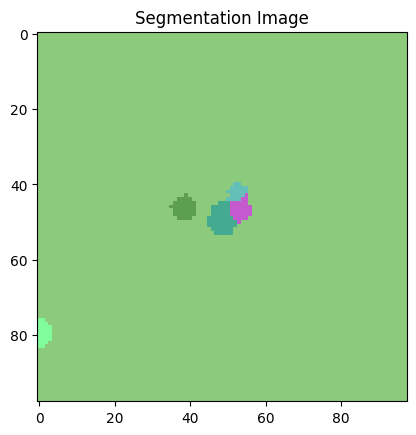

In [37]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
import sep
from photutils.utils import make_random_cmap  # noqa: F401


file_Ks = f"/home/matteo/MIRAGE/Simulazioni/simulazioni/data/{id}/Ks.fits"
# file_irac = "/home/matteo/blind_phoebo/mapper_spitzer/irac1.fits"
file_irac = (
    f"/home/matteo/MIRAGE/Simulazioni/simulazioni/data/{id}/IRAC{irac_band}.fits"
)

# file_rms_irac = f"/home/matteo/MIRAGE/Simulazioni/simulazioni/Sky_IRAC{irac_band}.fits"


cut_irac = fits.open(file_irac)[0].data

cut_Ks = fits.open(file_Ks)[0].data

# creazione dei cutout
# wcs_Ks = WCS(Ks[0].header)

# coordinate centrali del cutout
# coords = SkyCoord(157.58281111724017 ,5.388709222108544, unit="deg")
# coords = SkyCoord(ra, dec, unit="deg")
# dim = u.Quantity(dim_cutout, "arcsec")


# MAPPA DI SEGMENTAZIONES
mean, median, std = sigma_clipped_stats(cut_Ks)

Ks_object, Ks_seg = sep.extract(
    cut_Ks.byteswap().newbyteorder(),
    thresh=median + 2 * std,
    minarea=5,
    segmentation_map=True,
    deblend_cont=1e-4,
    deblend_nthresh=64,
)

plt.imshow(Ks_seg, cmap=make_random_cmap(len(Ks_object) + 1))
plt.title("Segmentation Image")
plt.show()

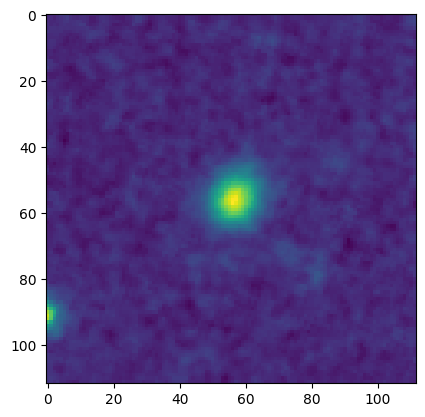

In [38]:
plt.imshow(cut_irac)

In [39]:
my_model = SersicModel(
    x0=55,
    y0=55,
    ellip = 0.,
    re=200,
    n=4,
    ) | psf

print(my_model)

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['SersicModel', 'PSF']
GRID VARIABLES: ['x', 'y']
LOGIC: (SersicModel [0] | PSF [1])
FREE PARAMS: 7
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    amp_0           1.00       0          (-inf, inf)         
1    re_0            200.00     0          (-inf, inf)         
2    n_0             4.00       0          (-inf, inf)         
3    x0_0            55.00      0          (-inf, inf)         
4    y0_0            55.00      0          (-inf, inf)         
5    ellip_0         0.00       0          (-inf, inf)         
6    theta_0         1.00       0          (-inf, inf)         



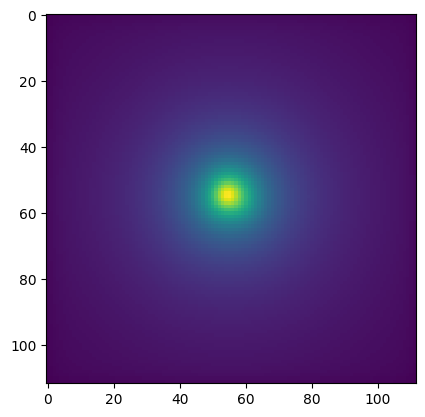

In [40]:
x = np.linspace(0, np.shape(cut_irac)[0], np.shape(cut_irac)[0])
y = np.linspace(0, np.shape(cut_irac)[1], np.shape(cut_irac)[1])
X, Y = np.meshgrid(x, y)



plt.imshow(my_model([X,Y],))
plt.show()

In [45]:
from optimizers import NelderMead


initial_guess = {
    "amp_0": 1e-2,
    "re_0": 3,
    "n_0": 1.4,
    "x0_0": 64.95,
    "y0_0": 35,
    "ellip_0": 0,
    "theta_0": 0.5,
} # [mu, sigma, A]

#initial_guess =  my_model.parameters_values

optimizer = NelderMead(model=my_model, treshold=1e-6, delta=.4)


results = optimizer.minimize(
    x0=initial_guess, grid=[X, Y], data=[cut_irac], progress=True
)

print(results)

  2%|▏         | 39/2100 [00:00<00:15, 131.20it/s]

Treshold raggiunta
[2.40673529e-04 2.80310946e+00 1.32648663e+00 6.49724466e+01
 3.50970822e+01 3.58306700e-01 3.44020986e-01]


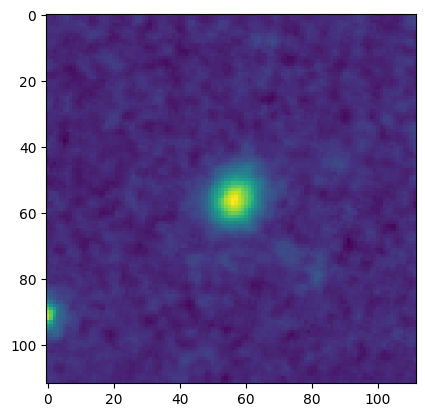

In [46]:
plt.imshow(cut_irac-my_model([X,Y], results))